# DarkNESS ALP allowed-signal ceiling

A **go/no-go theory screen**: is the largest externally allowed
$\phi_{\rm DM}\rightarrow a+a,\ a+B_\oplus\rightarrow\gamma$ signal even in the
countable regime for DarkNESS?

It now runs on the simulated mission, not on hand-set numbers: the orbit is
propagated from CCSDS elements, the boresight holds the Galactic Centre, and
the conversion kernel $K$ and the halo column $D$ are averaged over the 20°
aperture sample by sample (`sim.state_table`). Only umbra samples with the
sky in view count as exposure. Two ceilings:

1. **Milky Way line**, from the NFW column density $D$ in the field of view;
2. **extragalactic continuum**, the Yamamoto 2020 surface-brightness limit
   rescaled to the benchmark coupling and decay rate.

References: [DarkNESS](https://doi.org/10.1016/j.asr.2025.07.070),
[Yamamoto et al.](https://arxiv.org/abs/1906.04429),
[CAST bound](https://arxiv.org/abs/2406.16840),
[invisible-decay cosmology](https://arxiv.org/abs/1606.02073).

## Model and scaling

For a parent decay independent of the photon coupling,
$N_\gamma\propto g_{a\gamma\gamma}^2\,f_\phi\mathrm{Br}(\phi\to aa)/\tau_\phi$ —
**not** $g^4$, which applies only when production also runs through the
photon coupling (solar axions).

Conversion uses Yamamoto's normalisation with the simulated kernel
$K=|\int\mathbf B_\perp e^{iqs}ds|^2$ in place of a single $(B_\perp L)^2$:

$$P_{a\to\gamma}=2.45\times10^{-21}\left(\frac{g_{a\gamma\gamma}}{10^{-10}\,\mathrm{GeV}^{-1}}\right)^2\frac{K}{1\,\mathrm{T^2\,m^2}},\qquad q=\frac{m_a^2}{2E}.$$

Counts sum $P$ over the schedule, so the pointing enters only through
$\sum_i\langle K\rangle_i\Delta t_i$ (continuum) and
$\sum_i\langle D\,K\rangle_i\Delta t_i$ (line). Mass dependence comes from the
phase-aware integral itself, not a uniform-field $\mathrm{sinc}^2$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from darknessalp import field, frames, geometry, orbit, pointing, sim
from darknessalp.constants import R_EQUATOR_KM

# mission: the main-sequence reference case
EPOCH = "2027-05-01T00:00:00"                        # UTC
ELEMENTS = dict(a_km=R_EQUATOR_KM + 420.0, e=0.0, inc_deg=51.6,
                raan_deg=0.0, argp_deg=0.0, nu_deg=0.0)  # CCSDS OPM, GCRF
GRAVITY, LMAX = "j2", 13
CADENCE_S, DURATION_S = 60.0, 86400.0               # one simulated day
TARGET = "gc"                                        # fixed inertial boresight
MISSION_DAYS = 187                                   # DN-V p. 4799 science phase

# theory benchmark: the largest externally allowed values
PARENT_MASS_KEV = 7.0
G_GEV_INV = 5.8e-11                                  # CAST 2024
DECAY_RATE_GYR = 6.3e-3                              # f Br / tau, invisible decay

# instrument (DN-V; throughput is the LimitCalculation value, Q2)
AREA_CM2, HALF_ANGLE_DEG, THROUGHPUT = 12.0, 10.0, 0.20

# Yamamoto 2020 continuum limit, 2-6 keV, dN/dE ~ E^(1/2)
Y_FLUX_ERG_CM2_S_SR, Y_G_GEV_INV, Y_TAU_S, Y_K_T2M2 = 1.6e-9, 3.3e-7, 4.32e17, 1.0e4
E_LO_KEV, E_HI_KEV = 2.0, 6.0

S_PER_GYR, ERG_PER_KEV, HBAR_C_EV_M = 3.15576e16, 1.602176634e-9, 1.973269804e-7

## 1. Simulate the mission: orbit, pointing, kernel, halo column

In [2]:
t = np.arange(0.0, DURATION_S, CADENCE_S)
time = frames.times(EPOCH, t)
r0, v0 = orbit.elements_to_state(**ELEMENTS)
r, v = orbit.propagate(r0, v0, t, gravity=GRAVITY)
n = np.tile(pointing.sky_target(TARGET), (len(t), 1))
table = sim.state_table(EPOCH, t, r, n, lmax=LMAX, half_angle_deg=HALF_ANGLE_DEG)

sci = table["umbra"] & ~table["occulted"]           # science: umbra, sky in view
scale = CADENCE_S * MISSION_DAYS                     # one day stands for the mission
exposure_s = sci.sum() * scale
k_sum = table["k_fov_t2m2"][sci].sum() * scale      # T^2 m^2 s
dk_sum = table["dk_fov_gevcm2_t2m2"][sci].sum() * scale
print(f"science time {sci.sum() * CADENCE_S / 3600:.1f} h/day -> "
      f"{exposure_s / 1e6:.2f} Ms over {MISSION_DAYS} days")
print(f"exposure-weighted <K> {k_sum / exposure_s:.0f} T^2 m^2 "
      f"(sqrt: {np.sqrt(k_sum / exposure_s):.0f} T m)")
print(f"K-weighted halo column <D> {dk_sum / k_sum:.3e} GeV cm^-2")

science time 8.5 h/day -> 5.73 Ms over 187 days
exposure-weighted <K> 14604 T^2 m^2 (sqrt: 121 T m)
K-weighted halo column <D> 1.289e+23 GeV cm^-2


## 2. Coherent count ceilings

In [3]:
omega_sr = 2 * np.pi * (1 - np.cos(np.radians(HALF_ANGLE_DEG)))
grasp = AREA_CM2 * omega_sr                          # cm^2 sr
p_per_k = 2.45e-21 * (G_GEV_INV / 1e-10) ** 2        # P per T^2 m^2
rate_s = DECAY_RATE_GYR / S_PER_GYR

# Milky Way line: two ALPs per decay, isotropic, at E0 = m/2
line_per_d = 2 * rate_s / (4 * np.pi * PARENT_MASS_KEV * 1e-6)
line_counts = line_per_d * p_per_k * dk_sum * grasp * THROUGHPUT

# continuum: Yamamoto's limit rescaled in g^2, decay rate and K
e_mean = (0.6 * (E_HI_KEV**2.5 - E_LO_KEV**2.5)
          / (E_HI_KEV**1.5 - E_LO_KEV**1.5))         # mean E for E^(1/2)
y_photons = Y_FLUX_ERG_CM2_S_SR / (e_mean * ERG_PER_KEV)
cont_per_k = (y_photons * (G_GEV_INV / Y_G_GEV_INV) ** 2
              * rate_s * Y_TAU_S / Y_K_T2M2)
cont_counts = cont_per_k * k_sum * grasp * THROUGHPUT

print(f"grasp {grasp:.3f} cm^2 sr, P per unit K {p_per_k:.2e}")
print(f"Milky Way line ({PARENT_MASS_KEV / 2:g} keV): {line_counts:.2e} counts")
print(f"continuum (<E> {e_mean:.2f} keV):       {cont_counts:.2e} counts")
print("coupling for one count at the same source normalisation:")
print(f"  line      {G_GEV_INV / np.sqrt(line_counts):.2e} GeV^-1")
print(f"  continuum {G_GEV_INV / np.sqrt(cont_counts):.2e} GeV^-1")

grasp 1.145 cm^2 sr, P per unit K 8.24e-22
Milky Way line (3.5 keV): 9.25e-03 counts
continuum (<E> 4.17 keV):       1.22e-03 counts
coupling for one count at the same source normalisation:
  line      6.03e-10 GeV^-1
  continuum 1.66e-09 GeV^-1


## 3. Mass dependence from the phase-aware integral

$K$ depends on the ALP mass only through $q=m_a^2/2E$, so one scan over $q$
serves both energies. Boresight rays on a subsample of science frames; the
coherence is $\sum K(q)/\sum K(0)$.

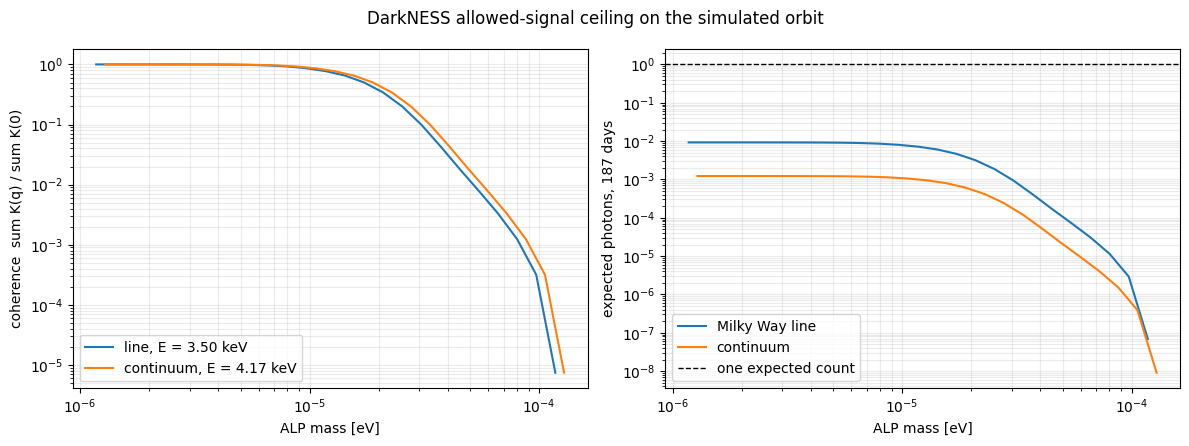

coherence falls to 1/2 at m = 1.7e-05 eV (line)


In [4]:
coeffs = field.load_igrf(float(np.mean(frames.decimal_year(time))))
frames_used = np.where(sci)[0][::8]
q_grid = np.geomspace(1e-9, 1e-5, 25)                # m^-1

def kernel_sum(q):
    return sum(geometry.los_field_integral(r[k], n[k], time[k], coeffs, lmax=LMAX,
                                           q_per_m=q)["amplitude_tm"][0] ** 2
               for k in frames_used)

coherence = np.array([kernel_sum(q) for q in q_grid]) / kernel_sum(0.0)

def mass_ev(e_kev):
    return np.sqrt(2 * e_kev * 1e3 * HBAR_C_EV_M * q_grid)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for e_kev, label in ((PARENT_MASS_KEV / 2, "line"), (e_mean, "continuum")):
    ax[0].loglog(mass_ev(e_kev), coherence, label=f"{label}, E = {e_kev:.2f} keV")
ax[0].set_xlabel("ALP mass [eV]"); ax[0].set_ylabel("coherence  sum K(q) / sum K(0)")
ax[1].loglog(mass_ev(PARENT_MASS_KEV / 2), line_counts * coherence, label="Milky Way line")
ax[1].loglog(mass_ev(e_mean), cont_counts * coherence, label="continuum")
ax[1].axhline(1.0, color="k", ls="--", lw=1, label="one expected count")
ax[1].set_xlabel("ALP mass [eV]"); ax[1].set_ylabel(f"expected photons, {MISSION_DAYS} days")
for a in ax:
    a.grid(True, which="both", alpha=0.25); a.legend()
fig.suptitle("DarkNESS allowed-signal ceiling on the simulated orbit")
fig.tight_layout()
plt.show()
print(f"coherence falls to 1/2 at m = {np.interp(0.5, coherence[::-1], mass_ev(PARENT_MASS_KEV / 2)[::-1]):.1e} eV (line)")

## Decision and next required evidence

- If the allowed ceiling is far below one count, no schedule rescues that
  benchmark: pointing changes $\sum\langle K\rangle\Delta t$ by a factor of
  a few, not by orders of magnitude.
- A sensitivity statement also needs DarkNESS background counts and their
  covariance with $K$, not the raw signal total.

Still needing authoritative values:

1. The full-cone 20° FOV convention and the off-axis aperture response.
2. Energy-dependent effective area, masking and live fraction (12 cm² vs the
   LimitCalculation 8 cm² × 0.20, Q2).
3. The cosmological bound for the chosen parent lifetime and decaying fraction.
4. Umbra time over the whole science phase: one simulated day stands for all
   187; the ISS-like beta angle cycles over ~60 days.
5. Absolute LEO background counts (particle, Earth glow) and their covariates.